In [ ]:
!pip install pgmpy
!sudo apt-get install graphviz graphviz-dev
!pip install pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 42.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 5 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be

In [ ]:
import pandas as pd
import numpy as np
from pgmpy.sampling import BayesianModelSampling
from pgmpy.models import BayesianNetwork
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from pgmpy.readwrite import BIFWriter

In [ ]:
FILES_PATHS = ['https://github.com/fez2010/detection_de_ivresse_au_volant/raw/refs/heads/main/datasets/DonneesTestSymptomatiqueDRE_A2012.xlsx']

datasets = []
for path in FILES_PATHS:
  #get csv file encoding
  df = pd.read_excel(path,converters={'nr_nan':lambda x: pd.NA if x == '' else int(x)})

  df.columns = df.columns.str.capitalize()
  datasets.append(df)

print(datasets[0].shape)
datasets[0].head()

(116, 50)


,Testno,Nistagmus horizontal,Nistagmus vertical,Convergence,Pupilles,Stimulus,Paupieres,Ambiant,Noirceur,Direct,...,Sautillement,Depot pied,Alcool,Dépresseur,Stimulant,Hallucinogène,Anesthésique dissociatif,Narcotique analgésique,Inhalant,Canabis
0,1,0,0,1,0,1,0,4.0,8.0,4.5,...,1.0,1.0,0,0,1,0,0,0,0.0,0
1,2,0,0,1,0,1,0,6.5,6.5,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
2,3,1,0,1,0,1,0,7.5,7.0,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
3,4,1,0,1,0,1,0,5.5,8.0,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
4,5,1,1,1,0,1,1,3.0,6.5,2.0,...,0.0,1.0,0,1,0,0,0,0,0.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Testno                    116 non-null    int64  
 1   Nistagmus horizontal      116 non-null    int64  
 2   Nistagmus vertical        116 non-null    int64  
 3   Convergence               116 non-null    int64  
 4   Pupilles                  116 non-null    int64  
 5   Stimulus                  116 non-null    int64  
 6   Paupieres                 116 non-null    int64  
 7   Ambiant                   116 non-null    float64
 8   Noirceur                  116 non-null    float64
 9   Direct                    115 non-null    float64
 10  Dilatation bond           115 non-null    float64
 11  Reaction lum              115 non-null    float64
 12  Injection                 116 non-null    int64  
 13  Romberg 1                 113 non-null    float64
 14  Romberg 2 

In [ ]:
df['Nistagmus vertical']

,Nistagmus vertical
0,0
1,0
2,0
3,0
4,1
...,...
111,0
112,0
113,0
114,0


In [ ]:
def preparer_donnees_bayesian(df):
    # Nettoyage des noms de colonnes (espaces invisibles)
    df_clean = df.copy()
    df_clean.columns = df_clean.columns.str.strip()

    # --- 1. SIGNES VITAUX (Imputation par la Médiane avant discrétisation) ---
    for col in ['Pouls', 'Température', 'Tension a', 'Tension b']:
        if col in df_clean.columns:
            # On remplit les vides par la valeur normale/médiane pour ne pas biaiser le réseau
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    df_clean['Pouls_cat'] = pd.cut(df_clean['Pouls'], bins=[0, 60, 90, 300], labels=['Bas', 'Normal', 'Eleve'])
    df_clean['Temp_cat'] = pd.cut(df_clean['Température'], bins=[0, 36.2, 37.5, 45], labels=['Bas', 'Normal', 'Eleve'])
    df_clean['Tension_a_cat'] = pd.cut(df_clean['Tension a'], bins=[0, 120, 140, 250], labels=['Bas', 'Normal', 'Eleve'])
    df_clean['Tension_b_cat'] = pd.cut(df_clean['Tension b'], bins=[0, 70, 90, 150], labels=['Bas', 'Normal', 'Eleve'])

    # --- 2. PUPILLES ET LUMIÈRE ---
    for col in ['Ambiant', 'Noirceur', 'Direct']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            df_clean[f'{col}_cat'] = pd.cut(df_clean[col], bins=[0, 3.0, 5.0, 15], labels=['Myosis', 'Normal', 'Mydriase'])

    # Gestion spécifique de 'Dilatation bond' (souvent binaire ou manquante)
    if 'Dilatation bond' in df_clean.columns:
        df_clean['Dilatation bond_cat'] = df_clean['Dilatation bond'].fillna(0).apply(lambda x: 1 if x > 0 else 0)
    if 'Reaction lum' in df_clean.columns:
        df_clean['Reaction lum_cat'] = df_clean['Reaction lum'].fillna(0).apply(lambda x: 1 if x > 0 else 0)
    if 'Talon/orteille' in df_clean.columns:
        df_clean['Talon/orteille_cat'] = df_clean['Talon/orteille'].fillna(0).apply(lambda x: 1 if x > 0 else 0)
    if 'Nistagmus vertical' in df_clean.columns:
        df_clean['Nistagmus vertical_cat'] = df_clean['Nistagmus vertical'].fillna(0).apply(lambda x: 1 if x > 0 else 0)
    if 'Nistagmus horizontal' in df_clean.columns:
        df_clean['Nistagmus horizontal_cat'] = df_clean['Nistagmus horizontal'].fillna(0).apply(lambda x: 1 if x > 0 else 0)

    # --- 3. TESTS PSYCHOMOTEURS ---
    # Romberg : Si vide, on considère 'Echec' par prudence ou 'Inconnu'
    for col in ['Romberg 1', 'Romberg 2', 'Romberg 3']:
        if col in df_clean.columns:
            # On traite les NaN comme un échec au test (incapacité à le faire)
            df_clean[f'{col}_cat'] = df_clean[col].apply(lambda x: 'Echec' if (pd.isna(x) or abs(x - 30) > 5) else 'Reussi')

    for col in ['Equi g', 'Equi d']:
        if col in df_clean.columns:
            # Remplissage par 0 (instabilité totale) si vide
            df_clean[f'{col}_cat'] = pd.cut(df_clean[col].fillna(0), bins=[-1, 25, 31], labels=['Instable', 'Stable'])

    # Pas et erreurs de marche : NaN = 1 (on assume l'erreur si non mentionné "réussi")
    cols_erreurs = ['Arret marche', 'Pas hors ligne', 'Utilisation bras', 'Sautillement', 'Depot pied', 'Balancement']
    for col in cols_erreurs:
        if col in df_clean.columns:
            df_clean[f'{col}_cat'] = df_clean[col].fillna(1).apply(lambda x: 1 if x > 0 else 0)

    # --- 4. VARIABLES BINAIRES & CIBLES (NaN = 0) ---
    binaires_explicatives = [
         'Convergence', 'Pupilles',
        'Stimulus', 'Paupieres', 'Injection', 'Tonus musculaire', 'Yeux normaux',
        'Injecté sang', 'Conjonctive rouge', 'Larmoyant', 'Test toucher',
        'Perte equilibre', 'Depart hatif', 'Pivot incorrect'
    ]

    cibles = ['Alcool', 'Dépresseur', 'Stimulant', 'Hallucinogène',
              'Anesthésique dissociatif', 'Narcotique analgésique', 'Inhalant', 'Cannabis']

    for col in binaires_explicatives + cibles:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0).astype(int)

    # --- 5. PROFIL_ID (Doit être calculé sans NaN) ---
    def generer_id_profil(row):
        valeur = 0
        for i, cible in enumerate(cibles):
            if row.get(cible, 0) == 1:
                valeur += (2**i)
        return valeur

    df_clean['Profil_ID'] = df_clean.apply(generer_id_profil, axis=1)

    # --- 6. SÉLECTION FINALE (Vérification de l'existence des colonnes) ---
    colonnes_base = ['Profil_ID'] + [c for c in cibles if c in df_clean.columns]
    colonnes_cats = [c for c in df_clean.columns if '_cat' in c]
    colonnes_bins = [c for c in binaires_explicatives if c in df_clean.columns]

    return df_clean[colonnes_base + colonnes_cats + colonnes_bins]





In [ ]:
# Utilisation :
df_bayesian = preparer_donnees_bayesian(df)

In [ ]:
cibles = ['Alcool', 'Dépresseur', 'Stimulant', 'Hallucinogène',
              'Anesthésique dissociatif', 'Narcotique analgésique', 'Inhalant', 'Cannabis']
def decoder_profil(id_profil, liste_cibles):
    """
    Transforme un ID (0-255) en dictionnaire de présence/absence.
    """
    resultat = {}
    for i, cible in enumerate(liste_cibles):
        # Vérifie si le bit i est actif dans l'ID
        est_present = bool(id_profil & (1 << i))
        resultat[cible] = est_present
    return resultat
def verifier_sante_donnees(df_prepared):
    print("=== BILAN DE SANTÉ DU DATASET (116 lignes) ===")

    # 1. Vérification des valeurs manquantes après préparation
    nan_counts = df_prepared.isnull().sum()
    total_nan = nan_counts.sum()

    if total_nan == 0:
        print("✅ Aucune valeur manquante : Le nettoyage a réussi.")
    else:
        print(f"⚠️ Attention : Il reste {total_nan} valeurs manquantes.")
        print(nan_counts[nan_counts > 0])

    # 2. Vérification de la distribution du Profil_ID (Cibles combinées)
    nb_combinaisons = df_prepared['Profil_ID'].nunique()
    print(f"\n📊 Nombre de combinaisons de drogues détectées : {nb_combinaisons} sur 128 possibles.")

    # Affichage des 5 profils les plus fréquents
    print("\n🔝 Top 5 des profils dans vos données :")
    counts = df_prepared['Profil_ID'].value_counts().head(5)
    for pid, count in counts.items():
        # Utilise le décodeur que nous avons fait plus haut
        noms = [n for n, p in decoder_profil(pid, cibles).items() if p]
        label = ", ".join(noms) if noms else "Sain"
        print(f" - ID {pid} [{label}] : {count} cas")

    # 3. Alerte sur la rareté
    rare_profiles = (df_prepared['Profil_ID'].value_counts() == 1).sum()
    if rare_profiles > 0:
        print(f"\n💡 Note : {rare_profiles} profils n'apparaissent qu'une seule fois.")
        print("Le paramètre 'equivalent_sample_size=10' dans l'entraînement sera crucial.")

# Appel du test
# df_bayesian = preparer_donnees_bayesian(df_original)
verifier_sante_donnees(df_bayesian)

=== BILAN DE SANTÉ DU DATASET (116 lignes) ===
⚠️ Attention : Il reste 34 valeurs manquantes.
Equi g_cat    14
Equi d_cat    20
dtype: int64

📊 Nombre de combinaisons de drogues détectées : 15 sur 128 possibles.

🔝 Top 5 des profils dans vos données :
 - ID 0 [Sain] : 25 cas
 - ID 4 [Stimulant] : 23 cas
 - ID 2 [Dépresseur] : 21 cas
 - ID 3 [Alcool, Dépresseur] : 9 cas
 - ID 1 [Alcool] : 9 cas

💡 Note : 2 profils n'apparaissent qu'une seule fois.
Le paramètre 'equivalent_sample_size=10' dans l'entraînement sera crucial.


In [ ]:
df_bayesian.head()

,Profil_ID,Alcool,Dépresseur,Stimulant,Hallucinogène,Anesthésique dissociatif,Narcotique analgésique,Inhalant,Pouls_cat,Temp_cat,...,Injection,Tonus musculaire,Yeux normaux,Injecté sang,Conjonctive rouge,Larmoyant,Test toucher,Perte equilibre,Depart hatif,Pivot incorrect
0,4,0,0,1,0,0,0,0,Eleve,Normal,...,0,0,0,1,0,0,0,1,1,1
1,1,1,0,0,0,0,0,0,Eleve,Normal,...,0,0,0,1,0,0,4,1,0,1
2,1,1,0,0,0,0,0,0,Eleve,Normal,...,0,0,0,0,1,0,4,0,0,1
3,1,1,0,0,0,0,0,0,Eleve,Normal,...,0,0,0,0,1,0,5,0,0,1
4,2,0,1,0,0,0,0,0,Normal,Normal,...,0,0,1,0,0,0,5,1,0,0


In [ ]:
df_bayesian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Profil_ID                 116 non-null    int64   
 1   Alcool                    116 non-null    int64   
 2   Dépresseur                116 non-null    int64   
 3   Stimulant                 116 non-null    int64   
 4   Hallucinogène             116 non-null    int64   
 5   Anesthésique dissociatif  116 non-null    int64   
 6   Narcotique analgésique    116 non-null    int64   
 7   Inhalant                  116 non-null    int64   
 8   Pouls_cat                 116 non-null    category
 9   Temp_cat                  116 non-null    category
 10  Tension_a_cat             116 non-null    category
 11  Tension_b_cat             116 non-null    category
 12  Ambiant_cat               116 non-null    category
 13  Noirceur_cat              116 non-null    category

In [ ]:


# 1. SYMPTÔMES OCULAIRES (Mélange de binaires et catégorisés)
oculaires = [
    'Nistagmus horizontal_cat', 'Nistagmus vertical_cat', 'Convergence',
    'Pupilles', 'Stimulus', 'Paupieres', 'Ambiant_cat',
    'Noirceur_cat', 'Direct_cat', 'Dilatation bond_cat',
    'Reaction lum_cat', 'Yeux normaux', 'Injecté sang',
    'Conjonctive rouge', 'Larmoyant'
]

# 2. SIGNES VITAUX (Tous catégorisés par pd.cut)
vitaux = [
    'Pouls_cat', 'Temp_cat', 'Tension_a_cat', 'Tension_b_cat',
    'Tonus musculaire', 'Injection'
]

# 3. TESTS PSYCHOMOTEURS (Performance et Temps)
tests_mouvements = [
    'Romberg 1_cat', 'Romberg 2_cat', 'Romberg 3_cat',
    'Test toucher', 'Perte equilibre', 'Depart hatif',
    'Pivot incorrect', 'Equi g_cat', 'Equi d_cat'
]

# 4. ERREURS DE MARCHE (Binaires : 0 ou 1)
tests_erreurs = [
    'Arret marche_cat', 'Pas hors ligne_cat', 'Utilisation bras_cat',
    'Sautillement_cat', 'Depot pied_cat', 'Balancement_cat', 'Talon/orteille_cat'
]
# 2. Création de la liste des arcs (Profil_ID -> Symptôme)
toutes_explicatives = oculaires + vitaux + tests_mouvements + tests_erreurs
edges = [('Profil_ID', var) for var in toutes_explicatives]

# 3. Initialisation du modèle discret
model_final = DiscreteBayesianNetwork(edges)

print(f"Structure créée : {len(model_final.nodes())} nœuds et {len(model_final.edges())} relations.")

Structure créée : 38 nœuds et 37 relations.


In [ ]:
# Liste complète de vos cibles
cibles = [
    'Alcool', 'Dépresseur', 'Stimulant', 'Hallucinogène',
    'Anesthésique dissociatif', 'Narcotique analgésique', 'Inhalant', 'Cannabis'
]
def generer_id_profil(row):
    """
    Transforme les 8 colonnes binaires en un entier unique (0-255).
    Ex: Alcool seul = 1, Alcool + Cannabis = 129, etc.
    """
    valeur = 0
    for i, cible in enumerate(cibles):
        if row[cible] == 1:
            valeur += (2**i)
    return valeur


In [ ]:
df_bayesian.head()

,Profil_ID,Alcool,Dépresseur,Stimulant,Hallucinogène,Anesthésique dissociatif,Narcotique analgésique,Inhalant,Pouls_cat,Temp_cat,...,Injection,Tonus musculaire,Yeux normaux,Injecté sang,Conjonctive rouge,Larmoyant,Test toucher,Perte equilibre,Depart hatif,Pivot incorrect
0,4,0,0,1,0,0,0,0,Eleve,Normal,...,0,0,0,1,0,0,0,1,1,1
1,1,1,0,0,0,0,0,0,Eleve,Normal,...,0,0,0,1,0,0,4,1,0,1
2,1,1,0,0,0,0,0,0,Eleve,Normal,...,0,0,0,0,1,0,4,0,0,1
3,1,1,0,0,0,0,0,0,Eleve,Normal,...,0,0,0,0,1,0,5,0,0,1
4,2,0,1,0,0,0,0,0,Normal,Normal,...,0,0,1,0,0,0,5,1,0,0


In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

# 1. Définition des arcs (Edges) reliant le Profil_ID aux variables explicatives
# Profil_ID est le nœud parent représentant la combinaison des 8 substances
edges_complets = []
explicatives = oculaires + vitaux + tests_mouvements + tests_erreurs

for var in explicatives:
    edges_complets.append(('Profil_ID', var))

# 2. Instanciation du nouveau modèle discret
model_sain = DiscreteBayesianNetwork(edges_complets)


In [ ]:
# Entraînement robuste
model_sain.fit(
    df_bayesian,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

# Vérification de la structure
print(f"Modèle valide : {model_sain.check_model()}")

Modèle valide : True


In [ ]:
def diagnostic_expert(donnees_observation):
    """
    donnees_observation : dict des symptômes (ex: {'Pouls_cat': 'Eleve', 'Nistagmus': 1})
    """
    inference = VariableElimination(model_sain)

    # Calcul de la distribution de probabilité sur Profil_ID
    query_result = inference.query(variables=['Profil_ID'], evidence=donnees_observation)

    # Extraction des 3 meilleures probabilités
    indices = np.argsort(query_result.values)[::-1][:3]

    print("--- RÉSULTATS DU RÉSEAU BAYÉSIEN DISCRET ---")
    for idx in indices:
        prob = query_result.values[idx]
        if prob > 0.01:
            # On utilise le décodeur bitwise (vu précédemment) pour lire les drogues
            combinaison = decoder_profil(idx, cibles)
            noms = [n for n, p in combinaison.items() if p]
            label = ", ".join(noms) if noms else "Négatif (Sain)"
            print(f"Probabilité {prob:.1%} : [{label}]")

# Exemple d'appel :


In [ ]:
diagnostic_expert({'Nistagmus horizontal_cat': 1, 'Pouls_cat': 'Normal', 'Convergence': 1})

--- RÉSULTATS DU RÉSEAU BAYÉSIEN DISCRET ---
Probabilité 41.3% : [Dépresseur]
Probabilité 18.1% : [Alcool, Dépresseur]
Probabilité 14.1% : [Dépresseur, Stimulant]


In [ ]:
# 1. Séparation des données (80% train, 20% test)
train, test = train_test_split(df_bayesian, test_size=0.2, random_state=42)
# 2. Instanciation du nouveau modèle discret
model_final = DiscreteBayesianNetwork(edges_complets)
# 2. Ré-entraînement du modèle sur le jeu d'entraînement uniquement
model_final.fit(train, estimator=BayesianEstimator, prior_type="BDeu")
noeuds_du_modele = list(model_final.nodes())
# On retire 'Profil_ID' car c'est ce qu'on veut prédire, pas une preuve (evidence)
variables_evidence = [n for n in noeuds_du_modele if n != 'Profil_ID']
# 3. Prédiction sur le jeu de test
def predire_test(model, test_df):
    inference = VariableElimination(model)
    y_true = test_df['Profil_ID'].astype(int).values
    y_pred = []

    # 1. On identifie les variables que le modèle connaît (ses nœuds)
    noeuds_du_modele = set(model.nodes())

    for i, (_, row) in enumerate(test_df.iterrows()):
        # 2. Construction de l'evidence : on ne garde que ce qui est utile
        evidence_dict = {}
        for col, val in row.to_dict().items():
            # On ignore Profil_ID et les colonnes que le modèle n'a pas dans son graphe
            if col in noeuds_du_modele and col != 'Profil_ID':
                # CRITIQUE : Convertir en string si c'est une catégorie,
                # et ignorer si c'est un NaN (pgmpy gère les données manquantes en prédiction)
                if pd.notna(val):
                    # Si c'est une colonne '_cat', on force le type string
                    evidence_dict[col] = str(val) if '_cat' in col else int(val)

        try:
            # 3. Requête MAP (Most Probable Explanation)
            resultat = inference.map_query(
                variables=['Profil_ID'],
                evidence=evidence_dict,
                show_progress=False
            )
            y_pred.append(resultat['Profil_ID'])
        except Exception as e:
            # Si ça plante encore sur une ligne, on met l'ID le plus fréquent (0 par défaut)
            print(f"Erreur à la ligne {i}: {e}")
            y_pred.append(0)

    return y_true, y_pred

# Exécution
y_true, y_pred = predire_test(model_final, test)

# 4. Affichage des résultats
acc = accuracy_score(y_true, y_pred)
print(f"🎯 Accuracy Globale (Profil Exact) : {acc:.2%}")

Erreur à la ligne 0: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 1: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 2: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 3: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 4: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 5: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 6: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 7: only i

Erreur à la ligne 13: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 14: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 15: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 16: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 17: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 18: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 19: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Erreur à la ligne 20

In [ ]:
# Vérification par substance (ex: Alcool)
def evaluer_par_substance(y_true, y_pred, cible_index):
    # On décode les ID pour voir si la substance (bit i) est présente
    true_substance = [(id >> cible_index) & 1 for id in y_true]
    pred_substance = [(id >> cible_index) & 1 for id in y_pred]

    return accuracy_score(true_substance, pred_substance)

# Exemple pour l'Alcool (index 0 dans notre liste cibles)
acc_alcool = evaluer_par_substance(y_true, y_pred, 0)
print(f"🍷 Accuracy spécifique Alcool : {acc_alcool:.2%}")

🍷 Accuracy spécifique Alcool : 79.17%


In [ ]:
from sklearn.metrics import f1_score, classification_report
def evaluer_par_substance_f1(y_true, y_pred, cible_index):
  # On décode les ID pour voir si la substance (bit i) est présente
    true_substance = [(id >> cible_index) & 1 for id in y_true]
    pred_substance = [(id >> cible_index) & 1 for id in y_pred]
    f1_macro = f1_score(true_substance, pred_substance, average='macro')
    f1_weighted = f1_score(true_substance, pred_substance, average='weighted')
    return f1_macro,f1_weighted
# On utilise les résultats y_true et y_pred obtenus précédemment
f1_macro,f1_weighted = evaluer_par_substance_f1(y_true, y_pred, 0)


print(f"Propriétés globales du modèle :")
print(f" - F1-Score (Macro) : {f1_macro:.2%}")
print(f" - F1-Score (Pondéré) : {f1_weighted:.2%}")

Propriétés globales du modèle :
 - F1-Score (Macro) : 44.19%
 - F1-Score (Pondéré) : 69.96%


In [ ]:
# On génère le rapport complet
# Note : zero_division=0 évite les erreurs si un profil n'a jamais été prédit
def evaluer_par_substance_report(y_true, y_pred, cible_index):
  # On décode les ID pour voir si la substance (bit i) est présente
    true_substance = [(id >> cible_index) & 1 for id in y_true]
    pred_substance = [(id >> cible_index) & 1 for id in y_pred]
    return classification_report(true_substance, pred_substance)
report = evaluer_par_substance_report(y_true, y_pred, 0)
print("\n=== RAPPORT DE PERFORMANCE PAR PROFIL ID ===")
print(report)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== RAPPORT DE PERFORMANCE PAR PROFIL ID ===
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        19
           1       0.00      0.00      0.00         5

    accuracy                           0.79        24
   macro avg       0.40      0.50      0.44        24
weighted avg       0.63      0.79      0.70        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_true, y_pred

(array([ 2,  2,  5,  3,  7,  2,  0, 36,  4,  5,  8,  6,  0, 32,  8,  4,  4,
         2,  0,  0,  0,  2,  4,  3]),
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
def calculer_f1_par_substance(y_true, y_pred, cibles):
    scores = {}
    for i, nom_substance in enumerate(cibles):
        # Extraction du bit i pour chaque prédiction (0 ou 1)
        y_true_sub = [(id >> i) & 1 for id in y_true]
        y_pred_sub = [(id >> i) & 1 for id in y_pred]

        scores[nom_substance] = f1_score(y_true_sub, y_pred_sub, average='macro')

    return scores

# Calcul et affichage
f1_substances = calculer_f1_par_substance(y_true, y_pred, cibles)

print("\n=== F1-SCORE PAR SUBSTANCE (Individuel) ===")
for substance, score in f1_substances.items():
    print(f" - {substance:25} : {score:.2%}")


=== F1-SCORE PAR SUBSTANCE (Individuel) ===
 - Alcool                    : 44.19%
 - Dépresseur                : 38.46%
 - Stimulant                 : 38.46%
 - Hallucinogène             : 47.83%
 - Anesthésique dissociatif  : 100.00%
 - Narcotique analgésique    : 47.83%
 - Inhalant                  : 100.00%
 - Cannabis                  : 100.00%


/tmp/ipykernel_5157/373467608.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=noms, y=valeurs, palette=np.array(pal)[rank])
/tmp/ipykernel_5157/373467608.py:17: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x=noms, y=valeurs, palette=np.array(pal)[rank])


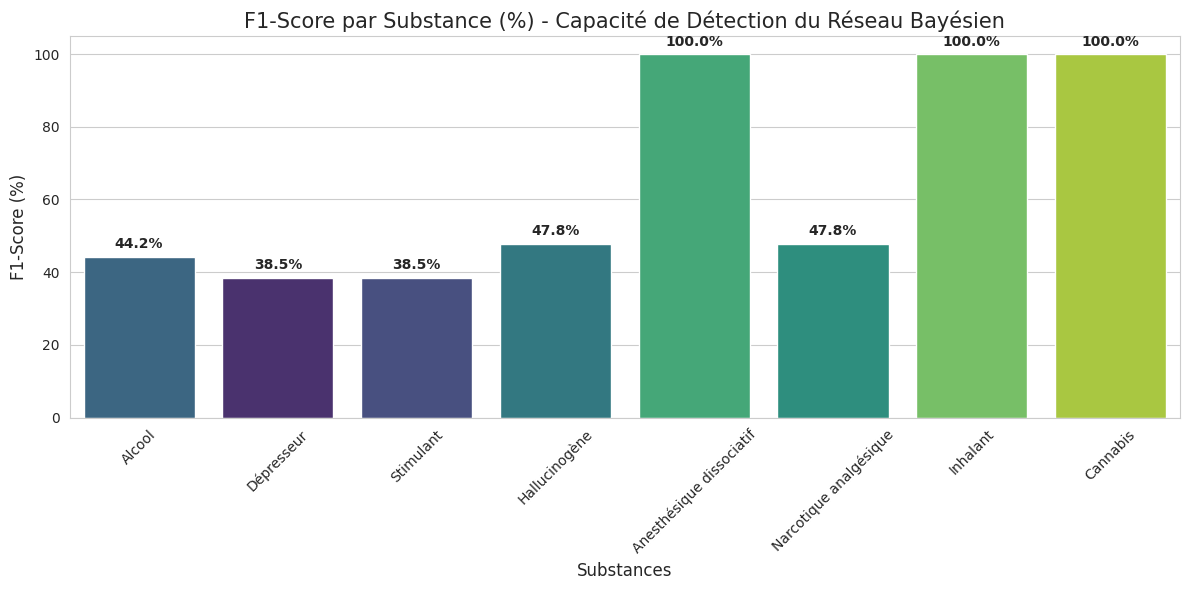

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def afficher_f1_comparaison(f1_scores_dict):
    # Préparation des données pour Seaborn
    noms = list(f1_scores_dict.keys())
    valeurs = [v * 100 for v in f1_scores_dict.values()] # Conversion en %

    # Création du graphique
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # Palette de couleurs dégradée selon la performance
    pal = sns.color_palette("viridis", len(valeurs))
    rank = np.argsort(np.argsort(valeurs))

    ax = sns.barplot(x=noms, y=valeurs, palette=np.array(pal)[rank])

    # Personnalisation
    plt.title("F1-Score par Substance (%) - Capacité de Détection du Réseau Bayésien", fontsize=15)
    plt.ylabel("F1-Score (%)", fontsize=12)
    plt.xlabel("Substances", fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 105) # On laisse de la place pour les étiquettes

    # Ajout des étiquettes de score au-dessus des barres
    for i, p in enumerate(ax.patches):
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Utilisation
# f1_substances = calculer_f1_par_substance(y_true, y_pred, cibles_global)
afficher_f1_comparaison(f1_substances)

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5157/3407508554.py:42: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Treillis de Boole des combinaisons (Ordre partiel $\subseteq$)\nEspace des états du Profil_ID", fontsize=14)


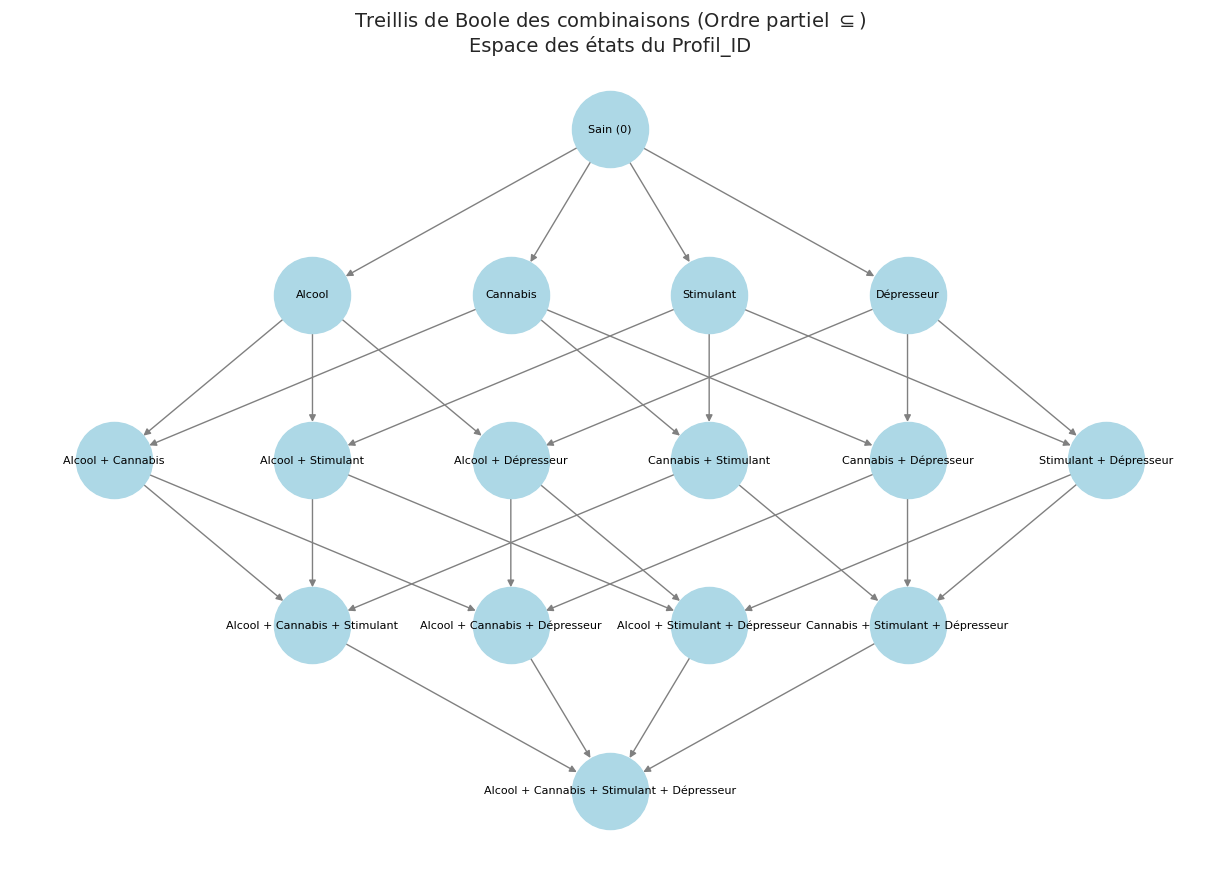

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

def generer_treillis_hasse(substances):
    G = nx.DiGraph()
    n = len(substances)

    # 1. Créer les nœuds par niveaux (0 à n substances)
    niveaux = []
    for r in range(n + 1):
        niveau = list(combinations(substances, r))
        niveaux.append(niveau)
        for node in niveau:
            label = " + ".join(node) if node else "Sain (0)"
            G.add_node(node, label=label, level=r)

    # 2. Créer les arcs (Inclusion : A est inclus dans B)
    for r in range(n):
        for source in niveaux[r]:
            for cible in niveaux[r+1]:
                if set(source).issubset(set(cible)):
                    G.add_edge(source, cible)

    # 3. Positionnement par couches (Multipartite)
    pos = {}
    for node, data in G.nodes(data=True):
        level = data['level']
        # Centrage horizontal
        nodes_in_level = [n for n, d in G.nodes(data=True) if d['level'] == level]
        idx = nodes_in_level.index(node)
        pos[node] = (idx - len(nodes_in_level)/2, -level)

    # 4. Affichage
    plt.figure(figsize=(12, 8))
    labels = {node: data['label'] for node, data in G.nodes(data=True)}

    nx.draw(G, pos, with_labels=True, labels=labels,
            node_color='lightblue', node_size=3000,
            font_size=8, edge_color='gray', arrows=True)

    plt.title(f"Treillis de Boole des combinaisons (Ordre partiel $\subseteq$)\nEspace des états du Profil_ID", fontsize=14)
    plt.show()

# Test avec les 4 premières substances pour la clarté
substances_demo = ['Alcool', 'Cannabis', 'Stimulant', 'Dépresseur']
generer_treillis_hasse(substances_demo)

In [ ]:



# Convert model into pygraphviz object
model_graphviz = model_final.to_graphviz()



# Other file formats can also be specified.
model_graphviz.draw("sachs.pdf", prog="dot")
model_graphviz.draw("sachs.svg", prog="dot")

# Plot the model.
model_graphviz.draw("sachs.png", prog="dot")

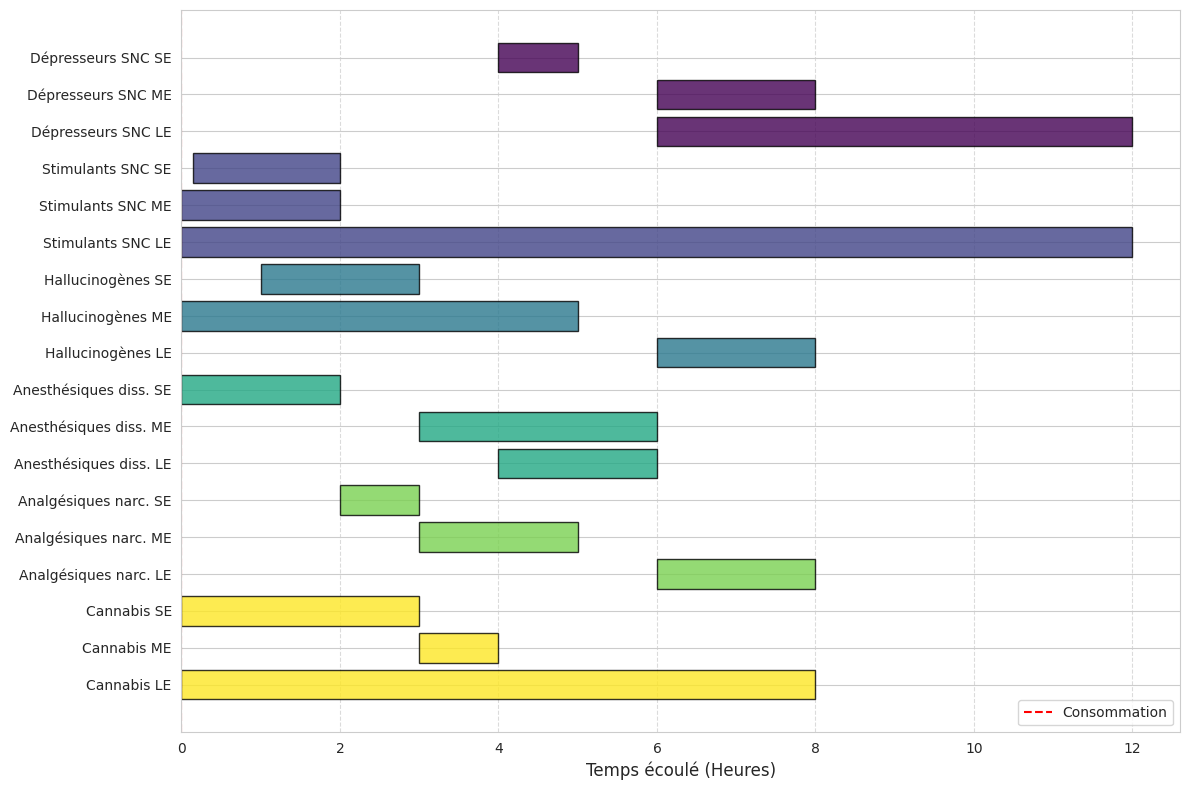

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Données utilisateur
drugs = ['Dépresseurs SNC', 'Stimulants SNC', 'Hallucinogènes',
         'Anesthésiques diss.', 'Analgésiques narc.', 'Cannabis']

# Reconstruction des labels SE, ME, LE
xlabels = []
for drug in drugs:
    xlabels.extend([f'{drug} SE', f'{drug} ME', f'{drug} LE'])

# Données temporelles fournies
timeStart = np.array([4, 6, 6, 0.15, 0, 0, 1, 0, 6, 0, 3, 4, 2, 3, 6, 0, 3, 0])
timeEnd = np.array([5, 8, 12, 2, 2, 12, 3, 5, 8, 2, 6, 6, 3, 5, 8, 3, 4, 8])

# Création du graphique
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(drugs)))

for i in range(len(xlabels)):
    color_idx = i // 3
    plt.barh(xlabels[i], timeEnd[i] - timeStart[i], left=timeStart[i],
             color=colors[color_idx], alpha=0.8, edgecolor='black')

plt.axvline(x=0, color='red', linestyle='--', label='Moment de consommation')
plt.xlabel('Temps écoulé (Heures)', fontsize=12)
#plt.title('Fenêtres d\'Opportunité Diagnostique (DRE) : Signes Physiques vs Temps', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis() # Inverser pour lire de haut en bas
plt.legend(['Consommation'], loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
writer = BIFWriter(model_final)
writer.write_bif('model_final.bif')


In [ ]:
df_bayesian.to_csv('df_bayesian.csv', index=False)

In [ ]:
import pickle

# On suppose que votre modèle s'appelle 'model'
# 'wb' signifie 'Write Binary' (écriture binaire)
with open('model_final.pkl', 'wb') as fichier:
    pickle.dump(model_final, fichier)

print("Modèle sauvegardé avec succès sous le nom 'model_final.pkl'")

Modèle sauvegardé avec succès sous le nom 'model_final.pkl'
